<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo8dec_vs_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


0: 512x640 5 birds, 393.4ms
Speed: 16.4ms preprocess, 393.4ms inference, 44.0ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 7 birds, 1 kite, 1 cake, 280.6ms
Speed: 5.7ms preprocess, 280.6ms inference, 22.8ms postprocess per image at shape (1, 3, 512, 640)


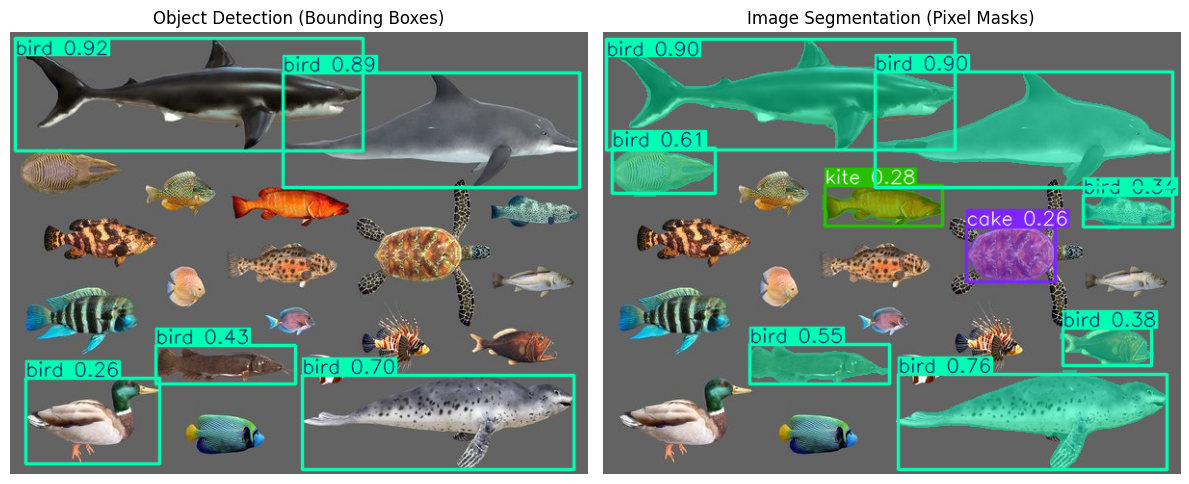

In [2]:
!pip install ultralytics opencv-python

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 테스트용 이미지 경로
image_path = "newimage.jpg"

# YOLO 모델 로드
det_model = YOLO("yolo11n.pt")           # detection 전용
seg_model = YOLO("yolo11n-seg.pt")   # segmentation 전용

img = cv2.imread(image_path)
assert img is not None, "이미지 로드 실패!"

# 1) Object Detection
det_results = det_model(img)[0]
det_img = det_results.plot()

# 2) Image Segmentation
seg_results = seg_model(img)[0]
seg_img = seg_results.plot()

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(det_img, cv2.COLOR_BGR2RGB))
plt.title("Object Detection (Bounding Boxes)")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB))
plt.title("Image Segmentation (Pixel Masks)")
plt.axis("off")

plt.tight_layout()
plt.show()